# **Ejercicios 8, 9 y 10 — Análisis de sentimiento y negatividad**

## **Enfoque**

Para el ejercicio 8 se necesita una función que reciba un tweet y determine qué tan positivo,
negativo o neutro es a partir de sus palabras. Se usa **VADER** (`vaderSentiment`) en lugar de
`TextBlob`, porque su léxico y sus reglas están construidos específicamente para texto de redes
sociales: pondera mayúsculas, signos de puntuación repetidos, negaciones ("not good") e
intensificadores ("very good"), que es justo el tipo de señal que un léxico genérico como el de
TextBlob ignora.

La función corre sobre `texto_sentimiento` y no sobre `tokens`, porque esa columna conserva
mayúsculas, puntuación y negaciones (ver `src/texto.py`, `normalizar_para_sentimiento`), que son
exactamente las señales que lee VADER. Si se usara la versión agresiva de limpieza, un texto donde
ya se quitó "not" como stopword se puntuaría con el sentido invertido.

Cabe mencionar que la lógica no se reescribe acá, sino que se importa de **`src/sentimiento.py`**,
que es el mismo módulo que usa la etapa 09 del pipeline. Se hizo así por la misma razón que
`texto.py`: la función estaba duplicada entre la etapa y el notebook y las dos copias habían
divergido, ya que la del pipeline no recortaba la puntuación antes de buscar en el léxico y por eso
"amazing," no coincidía con "amazing", dejando el conteo corto en el 12.9% de los tweets.

Sobre la pregunta de si vale la pena dejar los emoticones: en `src/decisiones.md` ya se midió que
los emoticones ASCII aparecen en menos del 1% de los tweets y que no hay ni un solo emoji unicode
en el dataset, así que no habría forma de que movieran el resultado a nivel de corpus. Dicho esto,
sí se leen cuando aparecen, ya que el léxico de VADER los incluye con sus signos (`:)`, `;)`) y la
función busca el token completo antes de recortarle la puntuación. En otras palabras, conservarlos
no cambia las conclusiones del análisis, no obstante tampoco cuesta nada aprovecharlos en los pocos
tweets que sí los traen.

Adicional, la clasificación en positivo, negativo o neutro se decide con el puntaje compuesto de
VADER y no contando a mano cuántas palabras positivas y negativas tiene el tweet. Los conteos se
reportan igual porque el enunciado los pide, no obstante el compuesto es mejor criterio, ya que
aplica las reglas de negación e intensidad que el conteo crudo ignora. Por ejemplo, "not good"
suma una palabra positiva en el conteo y sin embargo el compuesto lo puntúa como negativo.

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import config
import sentimiento as snt

SEMILLA = config.SEMILLA

## **Ejercicio 8 — Función de clasificación de sentimiento**

In [2]:
def clasificar_sentimiento(tweet, detalle=True):
    '''
    Recibe un tweet y determina si es positivo, negativo o neutro.

    Delega en src/sentimiento.py, que es el mismo modulo que usa la etapa 09
    del pipeline, de tal forma que la funcion y las columnas guardadas no
    pueden divergir.
    '''
    resultado = snt.puntuar_tweet(tweet)
    return resultado if detalle else resultado["sentimiento_clase"]

In [3]:
ejemplos = [
    "This is amazing, I love it so much! Best day ever :)",
    "This is horrible, I hate everything about this disaster",
    "The bus arrives at 5pm today",
]
pd.DataFrame([clasificar_sentimiento(t) for t in ejemplos])

,tweet,n_palabras_positivas,n_palabras_negativas,sentimiento_compound,negatividad,sentimiento_clase
0,"This is amazing, I love it so much! Best day e...",4,0,0.9499,0.000,positivo
1,"This is horrible, I hate everything about this...",0,3,-0.9197,0.668,negativo
2,The bus arrives at 5pm today,0,0,0.0000,0.000,neutro


La función reproduce lo esperado: el primer tweet queda como positivo con puntaje compuesto alto,
el segundo como negativo, y el tercero, al no traer carga emocional, como neutro con cero palabras
positivas y cero negativas.

Cabe mencionar que el primer tweet cuenta 4 palabras positivas y no 3, porque el emoticón `:)`
también está en el léxico de VADER y se busca antes de recortarle los signos al token. Esto además
ilustra por qué la clase se decide con el compuesto y no con el conteo, ya que un texto como
"awful ;) not good" tiene 2 palabras positivas contra 1 negativa y aun así el compuesto lo puntúa
como negativo, al aplicar la regla de negación sobre "not good".

In [4]:
train = pd.read_csv(config.RUTA_SENTIMIENTO_TRAIN)
test = pd.read_csv(config.RUTA_SENTIMIENTO_TEST)
for d in (train, test):
    d["tokens"] = d["tokens"].fillna("")

# Los ejercicios 8 y 9 describen el DATASET, asi que se responden sobre las 7,485
# filas completas. El ejercicio 10 si respeta la particion, porque ahi se entrena.
todo = pd.concat([train, test], ignore_index=True)

print(f"train: {len(train):,} | test: {len(test):,} | dataset completo: {len(todo):,}")
todo[["text", "n_palabras_positivas", "n_palabras_negativas",
      "sentimiento_compound", "negatividad", "sentimiento_clase"]].head()

train: 5,239 | test: 2,246 | dataset completo: 7,485


,text,n_palabras_positivas,n_palabras_negativas,sentimiento_compound,negatividad,sentimiento_clase
0,But no lies though. It's pays to be the oldest...,2,3,-0.2741,0.212,negativo
1,real magic in real life:\n\nwomen went missing...,0,2,-0.4588,0.182,negativo
2,@SenateMajLdr let's try to do our best to prev...,2,1,0.0516,0.139,positivo
3,I hope the only time I end up on TV is when I'...,1,2,-0.3818,0.217,negativo
4,17 killed in S'Arabia mosque suicide bombing\n...,0,4,-0.9552,0.559,negativo


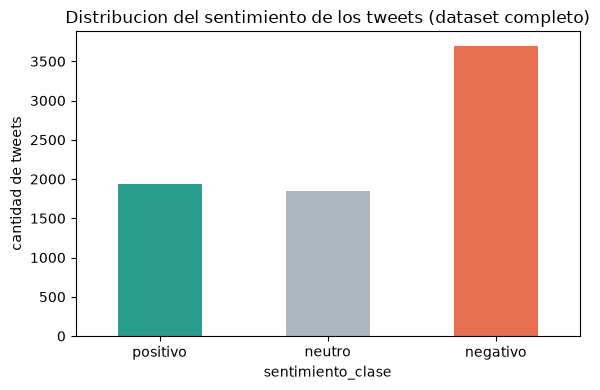

sentimiento_clase
negativo    3697
positivo    1937
neutro      1851 

sentimiento_clase
negativo    49.4%
positivo    25.9%
neutro      24.7%


In [5]:
conteo_clase = todo["sentimiento_clase"].value_counts()
conteo_clase_pct = (conteo_clase / len(todo) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
colores = {"positivo": "#2a9d8f", "negativo": "#e76f51", "neutro": "#adb5bd"}
conteo_clase.reindex(["positivo", "neutro", "negativo"]).plot(
    kind="bar", ax=ax, color=[colores[c] for c in ["positivo", "neutro", "negativo"]])
ax.set_title("Distribucion del sentimiento de los tweets (dataset completo)")
ax.set_ylabel("cantidad de tweets")
ax.set_xticklabels(["positivo", "neutro", "negativo"], rotation=0)
plt.tight_layout()
plt.show()

print(conteo_clase.to_string(), "\n")
print((conteo_clase_pct.astype(str) + "%").to_string())

**Ejercicio 8 — conclusión.** Casi la mitad del dataset se clasifica como negativo, con 3,697
tweets que son el 49.4%, contra un 25.9% de positivos y un 24.7% de neutros. Considero que tiene
sentido dado el tema del corpus, ya que se construyó buscando palabras clave de desastre y por eso
incluso los tweets que no hablan de un desastre real arrastran vocabulario cargado negativamente,
como `fire`, `crash` o `wreck` usados en sentido coloquial.

## **Ejercicio 9 — Tweets más negativos y más positivos**

### **9.1 Los 10 tweets más negativos**

In [6]:
mas_negativos = todo.sort_values("sentimiento_compound").head(10)[
    ["text", "sentimiento_compound", "negatividad", "target"]].reset_index(drop=True)
mas_negativos

,text,sentimiento_compound,negatividad,target
0,wreck? wreck wreck wreck wreck wreck wreck wre...,-0.9883,1.000,0
1,@Abu_Baraa1 Suicide bomber targets Saudi mosqu...,-0.9686,0.542,1
2,Suicide bomber kills 15 in Saudi security site...,-0.9623,0.522,1
3,? 19th Day Since 17-Jul-2015 -- Nigeria: Suici...,-0.9595,0.565,1
4,@dramaa_llama but otherwise i will stay trappe...,-0.9556,0.466,0
5,17 killed in S'Arabia mosque suicide bombing\n...,-0.9552,0.559,1
6,at the lake \n*sees a dead fish*\nme: poor lit...,-0.9549,0.507,0
7,illegal alien released by Obama/DHS 4 times Ch...,-0.9538,0.536,1
8,Bomb Crash Loot Riot Emergency Pipe Bomb Nucle...,-0.9524,0.566,1
9,@cspan #Prez. Mr. President you are the bigges...,-0.9493,0.496,1


In [7]:
print("categoria (target) de los 10 tweets mas negativos:")
print(mas_negativos["target"].value_counts().to_string())

categoria (target) de los 10 tweets mas negativos:
target
1    7
0    3


### **9.2 Los 10 tweets más positivos**

In [8]:
mas_positivos = todo.sort_values("sentimiento_compound", ascending=False).head(10)[
    ["text", "sentimiento_compound", "negatividad", "target"]].reset_index(drop=True)
mas_positivos

,text,sentimiento_compound,negatividad,target
0,Check out 'Want Twister Tickets AND A VIP EXPE...,0.9730,0.000,0
1,@thoutaylorbrown I feel like accidents are jus...,0.9564,0.049,0
2,Today's storm will pass; let tomorrow's light ...,0.9471,0.000,1
3,@Zak_Bagans pets r like part of the family. I ...,0.9428,0.000,0
4,@batfanuk we enjoyed the show today. Great fun...,0.9423,0.084,0
5,Maaaaan I love Love Without Tragedy by @rihann...,0.9394,0.000,0
6,Free Ebay Sniping RT? http://t.co/B231Ul1O1K L...,0.9376,0.000,0
7,I'm not a Drake fan but I enjoy seeing him bod...,0.9345,0.057,0
8,@duchovbutt @Starbuck_Scully @MadMakNY @davidd...,0.9344,0.000,0
9,Super sweet and beautiful :) https://t.co/TUi9...,0.9300,0.000,0


In [9]:
print("categoria (target) de los 10 tweets mas positivos:")
print(mas_positivos["target"].value_counts().to_string())

categoria (target) de los 10 tweets mas positivos:
target
0    9
1    1


### **9.3 ¿Son los tweets de desastre real más negativos que los otros?**

In [10]:
resumen = todo.groupby("target")[["sentimiento_compound", "negatividad"]].mean().round(4)
resumen.index = resumen.index.map({0: "no desastre", 1: "desastre real"})
resumen

,sentimiento_compound,negatividad
target,,
no desastre,-0.0527,0.1396
desastre real,-0.2682,0.1853


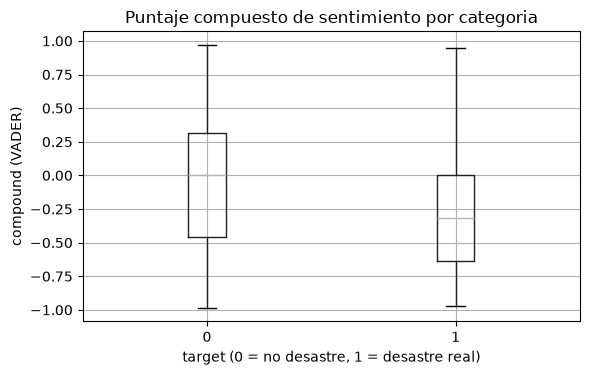

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
todo.boxplot(column="sentimiento_compound", by="target", ax=ax)
ax.set_title("Puntaje compuesto de sentimiento por categoria")
ax.set_xlabel("target (0 = no desastre, 1 = desastre real)")
ax.set_ylabel("compound (VADER)")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Ejercicio 9 — discusión.** De los 10 tweets más negativos del dataset, 7 pertenecen a la
categoría de desastre real y 3 no lo son. De los 10 más positivos ocurre lo contrario, con 9 de la
categoría de no desastre y solo 1 de desastre real. Es decir que los extremos sí se inclinan en la
dirección esperada, no obstante ninguna de las dos listas es pura, y esto ya adelanta que el
sentimiento por sí solo no alcanza como regla de clasificación.

Al comparar los promedios por grupo, los tweets de desastre real tienen un compuesto promedio de
**-0.2682** contra **-0.0527** de los que no lo son, y una negatividad promedio de **0.1853**
contra **0.1396**. Dicho esto, **sí son en promedio más negativos**, aunque la diferencia es
moderada y el boxplot muestra bastante traslape entre ambas distribuciones, de tal forma que
conviene usar el sentimiento como una variable más del modelo y no como criterio único.

## **Ejercicio 10 — Variable de negatividad en el modelo**

La variable `negatividad` ya quedó calculada en la etapa 9 del pipeline (componente `neg` de
VADER, en el rango [0, 1]) y está incluida en `09_sentimiento_train.csv` y
`09_sentimiento_test.csv`. A diferencia de los ejercicios 8 y 9, acá **sí se respeta la partición**,
ya que se entrena un modelo y hay que evaluarlo sobre datos que no vio.

Se reentrena la misma configuración ganadora del ejercicio 6 —**Random Forest, lematización,
unigramas, bolsa de palabras**— agregando `negatividad` como columna extra a la matriz de bolsa de
palabras, y se compara contra el modelo sin esa variable.

In [12]:
def metricas(y_real, y_pred):
    return {"accuracy": accuracy_score(y_real, y_pred), "precision": precision_score(y_real, y_pred),
            "recall": recall_score(y_real, y_pred), "f1": f1_score(y_real, y_pred)}


y_train, y_test = train["target"].values, test["target"].values

vectorizador = CountVectorizer(ngram_range=(1, 1), min_df=2)
X_train_bow = vectorizador.fit_transform(train["tokens"])
X_test_bow = vectorizador.transform(test["tokens"])

modelo_base = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                     n_jobs=-1, random_state=SEMILLA)
modelo_base.fit(X_train_bow, y_train)
m_base = metricas(y_test, modelo_base.predict(X_test_bow))

X_train_neg = hstack([X_train_bow, train[["negatividad"]].values]).tocsr()
X_test_neg = hstack([X_test_bow, test[["negatividad"]].values]).tocsr()

modelo_neg = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                    n_jobs=-1, random_state=SEMILLA)
modelo_neg.fit(X_train_neg, y_train)
m_neg = metricas(y_test, modelo_neg.predict(X_test_neg))

comparacion = pd.DataFrame([{"modelo": "sin negatividad", **m_base},
                            {"modelo": "con negatividad", **m_neg}]).round(4)
comparacion["diferencia_f1"] = (comparacion["f1"] - comparacion.loc[0, "f1"]).round(4)
comparacion

,modelo,accuracy,precision,recall,f1,diferencia_f1
0,sin negatividad,0.8059,0.7984,0.7283,0.7617,0.0000
1,con negatividad,0.7992,0.8100,0.6907,0.7456,-0.0161


**Ejercicio 10 — conclusión.** Se agrega `negatividad` como una columna numérica más a la matriz
dispersa de bolsa de palabras, con `scipy.sparse.hstack`, sin tocar el resto del pipeline de
vectorización, y se reentrena Random Forest con los mismos hiperparámetros del ejercicio 6 para que
la comparación sea limpia. El modelo base reproduce exactamente el f1 de 0.7617 del ejercicio 6, lo
cual confirma que la única diferencia entre ambas corridas es la variable agregada.

El resultado es que **la variable no mejoró el modelo**: el f1 bajó de 0.7617 a 0.7456, es decir
-0.0161, y la accuracy bajó de 0.8059 a 0.7992. Sube apenas la precisión, de 0.7984 a 0.8100, sin
embargo a costa de una caída más fuerte en el recall, de 0.7283 a 0.6907.

Considero que hay dos razones que se acumulan. Primero, lo visto en el ejercicio 9, donde el
sentimiento separa las clases solo de forma parcial y con bastante traslape, así que `negatividad`
no aporta información realmente nueva, ya que VADER calcula ese puntaje sobre el mismo texto que la
bolsa de palabras ya está viendo. Segundo, un problema de proporción: la matriz tiene 4,257 columnas
de vocabulario y el bosque usa `max_features='sqrt'`, o sea que evalúa unas 65 columnas por
división, de tal forma que esa única variable extra entra en consideración en apenas un 1.5% de las
divisiones y su señal se diluye en lugar de reforzar la decisión.